In [1]:
from src.preprocessing.io.feature_loader import FeatureLoader
from src.common.constants import Constants as consts
import pandas as pd
import numpy as np

feature_loader = FeatureLoader(feat_suffix=consts.wavlm_emb_suffix)

2026-04-28 20:05:40 | INFO     | FeatureLoader | Using WavLM embeddings suffix
2026-04-28 20:05:40 | INFO     | FeatureLoader | Constructed file path: /Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/data/collected_data/feature_extracted_wavlm.npy
2026-04-28 20:05:40 | INFO     | FeatureLoader | Constructed file path: /Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/data/collected_data/feature_extracted.csv


In [ ]:
# test eval

example_metadata = pd.DataFrame(
    {
        "unique_audio_id": ["audio1", "audio2", "audio3", "audio4", "audio5", "audio6"],
        "target": ["bonafide", "spoof", "bonafide", "spoof", "bonafide", "spoof"],
    }
)

mask = example_metadata.eval("""target == 'bonafide'""")
print(mask)

0     True
1    False
2     True
3    False
4     True
5    False
Name: target, dtype: bool


In [2]:
meta, feats = feature_loader.load_data()
print(feats.shape, meta.shape)

meta, feats = feature_loader.sample_data(metadata=meta, features=feats, fraction=0.2)
print(feats.shape, meta.shape)

2026-04-28 20:05:40 | INFO     | FeatureLoader | Loading features from /Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/data/collected_data/feature_extracted.csv
2026-04-28 20:05:40 | INFO     | FeatureLoader | Loading metadata from /Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/data/collected_data/feature_extracted.csv


(1125881, 768) (1125881, 10)
(225176, 768) (225176, 10)


In [ ]:
import matplotlib.pyplot as plt


def plot_umap_clusters(
    X_umap_2d, clusters, alpha=0.7, cmap="tab20", size=1, figsize=(10, 8), c=None
):
    print(np.sum(clusters == -1))  # Number of noise points
    print(np.unique(clusters, return_counts=True))
    plt.figure(figsize=figsize)
    if c is not None:
        plt.scatter(X_umap_2d[:, 0], X_umap_2d[:, 1], s=size, alpha=alpha, c=c)
    else:
        plt.scatter(
            X_umap_2d[:, 0], X_umap_2d[:, 1], s=size, alpha=alpha, c=clusters, cmap=cmap
        )
        plt.colorbar(label="Cluster Label")

    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.title("UMAP embeddings")
    plt.legend()
    plt.show()

In [ ]:
from umap import UMAP

umap_model = UMAP(
    n_components=2,
    n_neighbors=120,  # większe = gładsza struktura
    min_dist=0.35,  # większe = bardziej rozproszone klastry
    metric="cosine",
    random_state=42,
)

X_umap_2d = umap_model.fit_transform(feats)

In [ ]:
# np.save("./X_umap_2d.npy", X_umap_2d)

In [86]:
X_umap_2dx = np.load("./X_umap_2d.npy")

In [33]:
print(meta.columns)
print(meta["record_id"].dtype)

Index(['duration', 'starting_point', 'config', 'split', 'record_id',
       'speaker_id', 'target', 'unique_audio_id', 'cluster_id',
       'cluster_strength'],
      dtype='object')
int64


In [112]:
invalid_records_ids = [111, 1169, 1148, 1124, 1450, 1551]
expr = """config == 'mls-tts-fish_speech'
    and (split == 'dev' and record_id in @invalid_records_ids)
    or (split == 'test' and record_id == 1136)""".replace("\n", " ")
records = meta.query(expr)
grouped_records = records.groupby("record_id").count()

print(grouped_records)
print("Amount of grouped records:", grouped_records['duration'].sum())


expr2 = """(config == 'mls-tts-fish_speech'
    and (split == 'dev' and record_id in @invalid_records_ids)
    or (split == 'test' and record_id == 1136)) and starting_point >= 30.0""".replace("\n", " ")
records2 = meta.query(expr2)
grouped_records2 = records2.groupby("record_id").count()

print(grouped_records2)
print("Amount of grouped records:", grouped_records2['duration'].sum())

           duration  starting_point  config  split  speaker_id  target  \
record_id                                                                
111              31              31      31     31          31      31   
1124              1               1       1      1           1       1   
1136             66              66      66     66          66      66   
1148             42              42      42     42          42      42   
1169             46              46      46     46          46      46   
1450             12              12      12     12          12      12   
1551             26              26      26     26          26      26   

           unique_audio_id  cluster_id  cluster_strength  
record_id                                                 
111                     31          31                31  
1124                     1           1                 1  
1136                    66          66                66  
1148                    42          42

In [205]:
def plot_umap_with_invalid_samples(X_umap_2d, meta, mask, plot_title: str, figsize=(10, 8)):
    plt.figure(figsize=figsize)
    # 1) wszystkie próbki
    plt.scatter(
        X_umap_2d[:, 0],
        X_umap_2d[:, 1],
        s=1,
        alpha=0.4,
        c="gray",
        label="all_samples",
    )

    # 2) fish_speach
    fish = meta["config"] == "mls-tts-fish_speech"
    plt.scatter(
        X_umap_2d[:, 0][fish],
        X_umap_2d[:, 1][fish],
        s=1,
        alpha=0.4,
        c="tab:blue",
        label="fish_speach",
    )

    # 3) sampled_invalid_fish_speach
    plt.scatter(
        X_umap_2d[:, 0][mask],
        X_umap_2d[:, 1][mask],
        s=20,
        alpha=0.7,
        c="red",
        label="sampled_invalid_fish_speach",
        zorder=10,
    )

    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.title(plot_title)
    plt.legend(markerscale=3)
    plt.show()

# Plot all samples with fish_speach and with invalid samples of fish speach

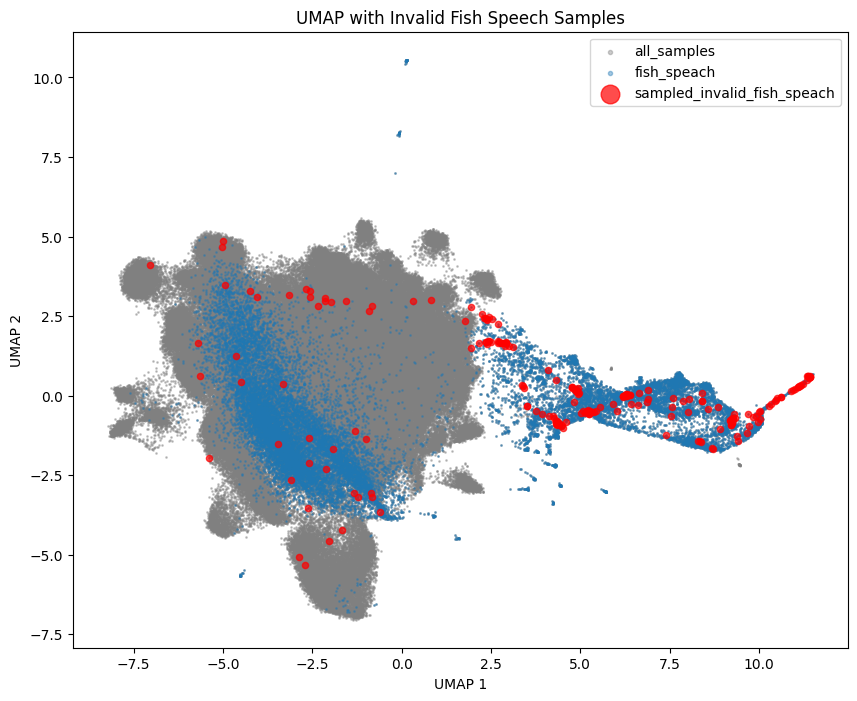

In [133]:
mask = meta.index.isin(records.index)
fish_speach_clusters = (meta["config"] == "mls-tts-fish_speech").astype(int)
labels = ["fish_speach", "other", "sampled_invalid_fish_speach"]


plot_umap_with_invalid_samples(X_umap_2d, meta, mask, plot_title="UMAP with Invalid Fish Speech Samples")

# Plot all samples with invalid samples that start after 30s 

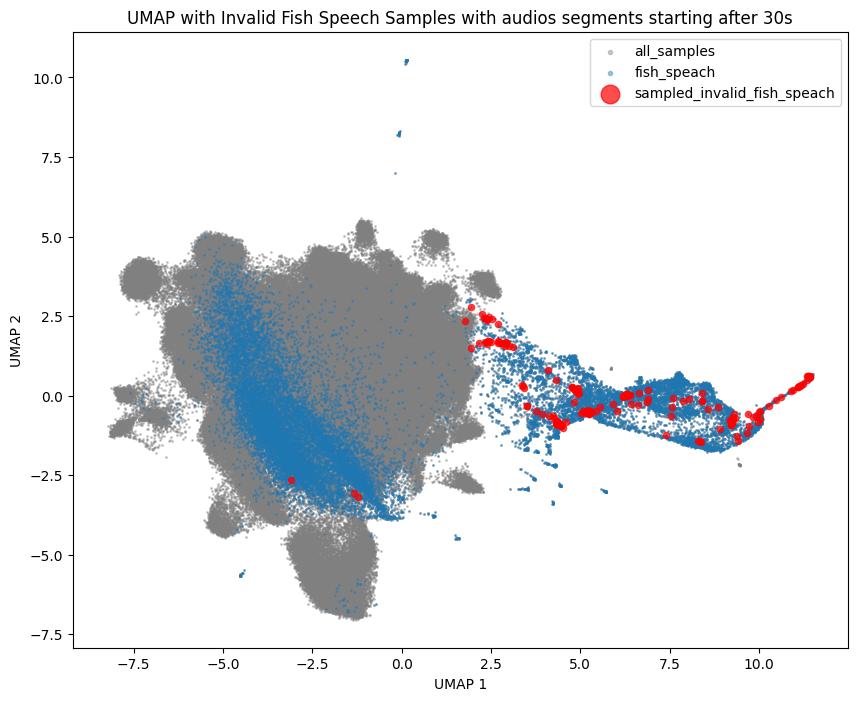

In [136]:
# 0 = other, 1 = fish_speach
mask2 = meta.index.isin(records2.index)
not_sampled = ~mask2
other = not_sampled & (fish_speach_clusters == 0)
fish = not_sampled & (fish_speach_clusters == 1)

plot_umap_with_invalid_samples(
    X_umap_2d, meta, mask2, plot_title="UMAP with Invalid Fish Speech Samples with audios segments starting after 30s"
)

# Plot all fish_speach where starting point >= 40s

In [165]:
all_meta, all_feats = feature_loader.load_data()
print(all_feats.shape, all_meta.shape)

2026-04-28 23:52:08 | INFO     | FeatureLoader | Loading features from /Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/data/collected_data/feature_extracted.csv
2026-04-28 23:52:08 | INFO     | FeatureLoader | Loading metadata from /Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/data/collected_data/feature_extracted.csv


(1125881, 768) (1125881, 10)


In [166]:
expr_40s = """(split == 'dev' or split == 'test') and starting_point >= 35.0"""
records40s = all_meta.query(expr_40s)
print(records40s['config'].value_counts())

config
mls-tts-fish_speech    38619
mls-tts-sparktts          22
mls-tts-chattts           12
Name: count, dtype: int64


config
mls-tts-fish_speech    7833
mls-tts-sparktts          7
mls-tts-chattts           3
Name: count, dtype: int64
Length of records40s: 7843
Length of mask40s: 7843
Length of meta: 225176


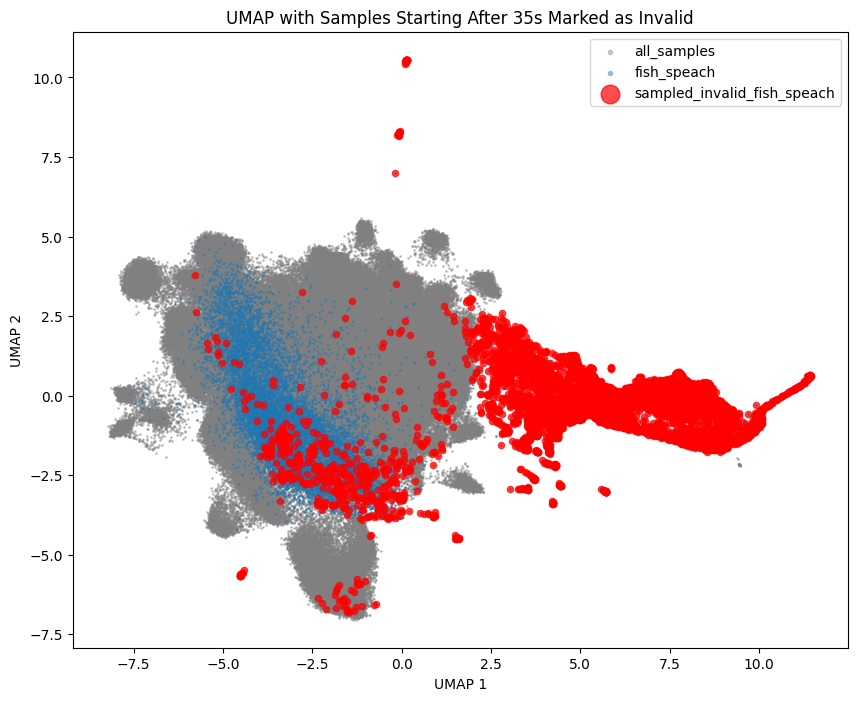

In [192]:
expr_40s = """(split == 'dev' or split == 'test') and starting_point >= 35.0"""
records40s = meta.query(expr_40s)

print(records40s['config'].value_counts())

mask40s = meta.index.isin(records40s.index)

print("Length of records40s:", len(records40s))
print("Length of mask40s:", np.sum(mask40s))
print("Length of meta:", len(meta))

plot_umap_with_invalid_samples(
    X_umap_2d, meta, mask40s, plot_title="UMAP with Samples Starting After 35s Marked as Invalid"
)

# Plot data using TSNE

In [ ]:

from sklearn.manifold import TSNE
from sklearn.preprocessing import Normalizer
normalizer = Normalizer("l2")
norm_all = normalizer.fit_transform(feats)
tsne = TSNE(n_components=2, random_state=44)
reduced_tsne = tsne.fit_transform(norm_all)
# 11.52 min xD

In [ ]:
# import numpy as np
# from src.common.constants import Constants as consts
# np.save(str(consts.data_dir) + "/results/tsne_all_feats_20p.npy", reduced_tsne)

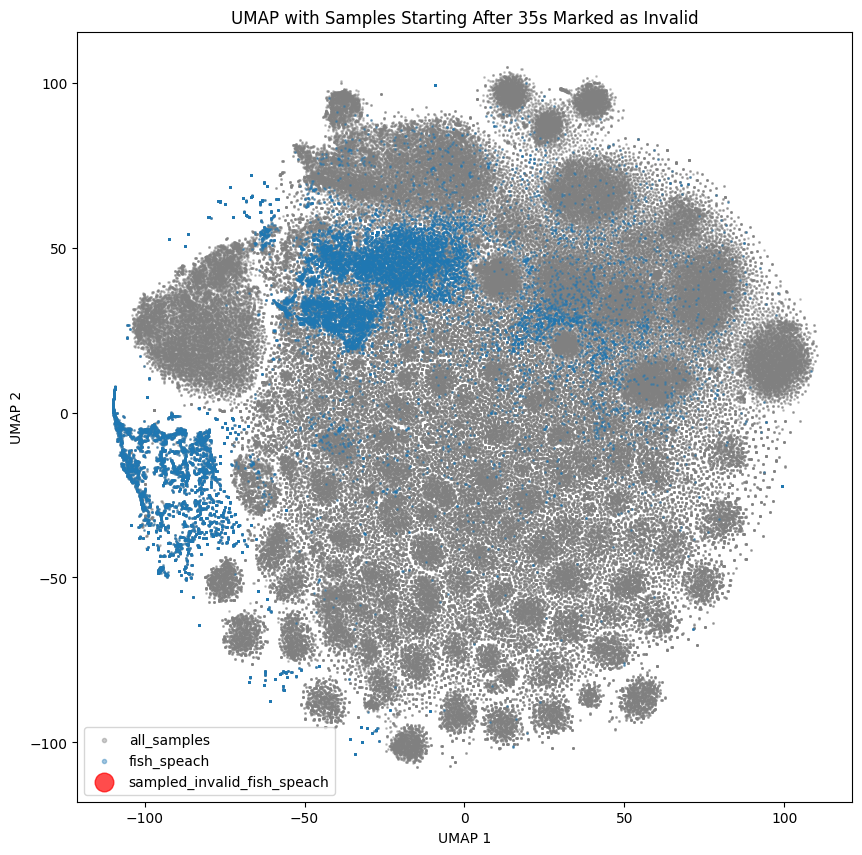

In [209]:
plot_umap_with_invalid_samples(
    reduced_tsne, meta, np.zeros(len(reduced_tsne), dtype=bool), plot_title="UMAP with Samples Starting After 35s Marked as Invalid", figsize=(10, 10)
)

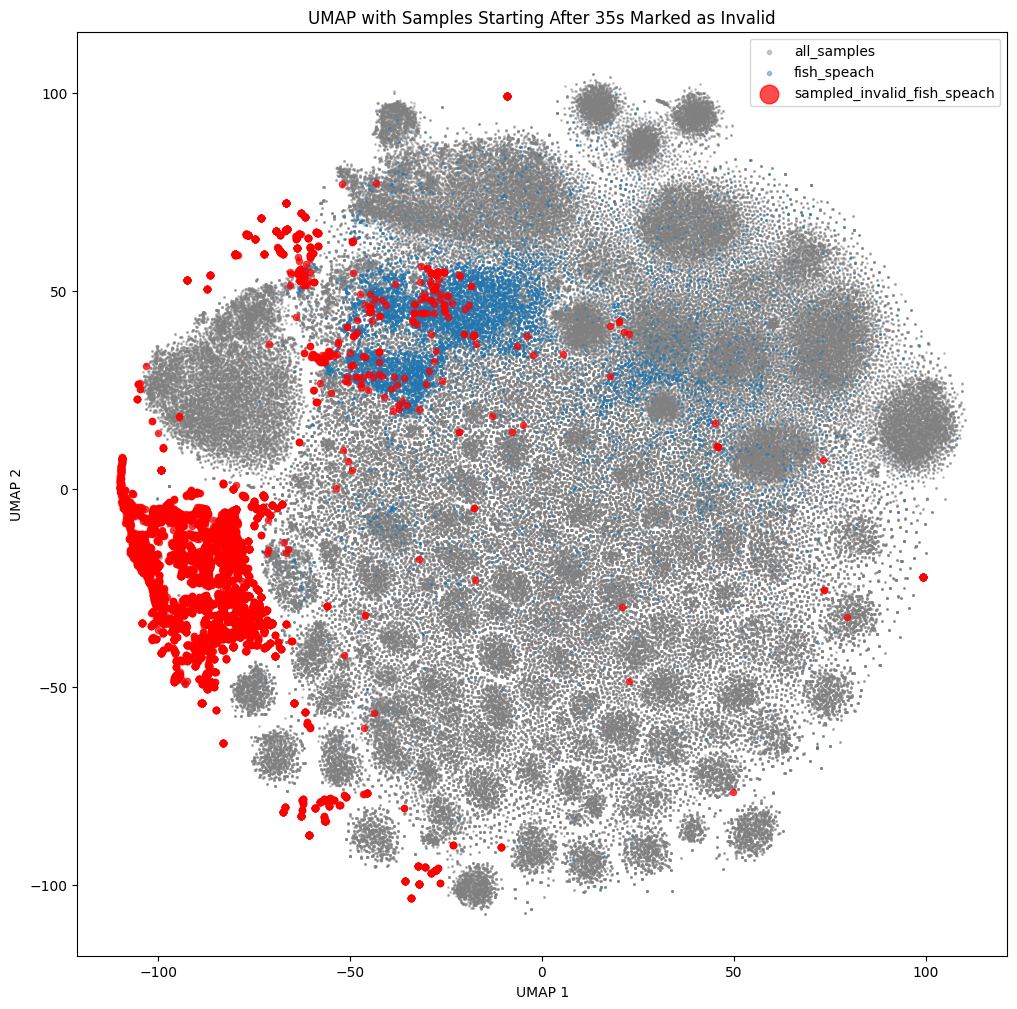

In [211]:
plot_umap_with_invalid_samples(
    reduced_tsne,
    meta,
    mask40s,
    plot_title="UMAP with Samples Starting After 35s Marked as Invalid",
    figsize=(12, 12),
)

# Plot All Data Except Fish Speach

0
(array([0]), array([202504]))


/var/folders/1d/mv_j9c7964b105nch0pj7kgh0000gn/T/ipykernel_81147/3371754204.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


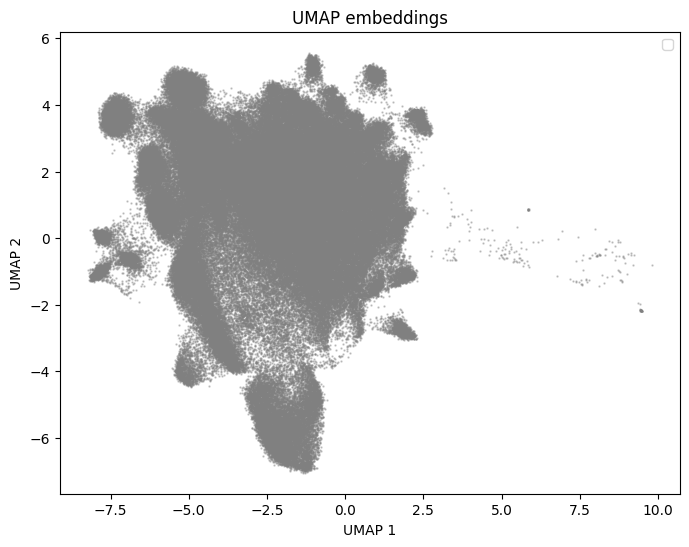

In [149]:
fish_speach_clusters = (meta["config"] == "mls-tts-fish_speech").astype(int)

no_fish = meta["config"] != "mls-tts-fish_speech"
plot_umap_clusters(
    X_umap_2d[no_fish], fish_speach_clusters[no_fish], alpha=0.4, c="gray", size=0.5, figsize=(8, 6)
)

# Other plots

In [29]:
print(meta["config"].value_counts())

clusters = meta["config"].map(
    dict(zip(meta["config"].unique(), range(len(meta["config"].unique()))))
)
print(clusters.value_counts().sort_index())

config
mls-tts-fish_speech               22672
mls-tts-f5_tts                    14861
mls-tts-chattts                   13917
mls-vocoders-univnet              10570
mls-vocoders-bigvsan              10570
mls-vocoders-bigvgan              10529
mls-vocoders-hifigan              10525
mls-vocoders-style_melgan         10484
mls-vocoders-vocos                10454
mls-vocoders-multi_band_melgan    10437
mls-bonafide                      10415
mls-vocoders-full_band_melgan     10383
mls-vocoders-melgan               10362
mls-vocoders-parallel_wavegan     10335
mls-tts-sparktts                   9370
mls-tts-bark                       8992
mls-tts-zonos                      8612
mls-tts-yourtts                    8329
mls-tts-xtts                       8310
mls-tts-cosyvoice                  8298
mls-tts-vits                       6751
Name: count, dtype: int64
config
0     13917
1     10529
2      8310
3     10525
4     14861
5      9370
6     22672
7      8612
8     10335
9     10362


0
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20]), array([13917, 10529,  8310, 10525, 14861,  9370, 22672,  8612, 10335,
       10362, 10484, 10383, 10454, 10570, 10570, 10437, 10415,  8329,
        8992,  8298,  6751]))


/var/folders/1d/mv_j9c7964b105nch0pj7kgh0000gn/T/ipykernel_81147/700841871.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


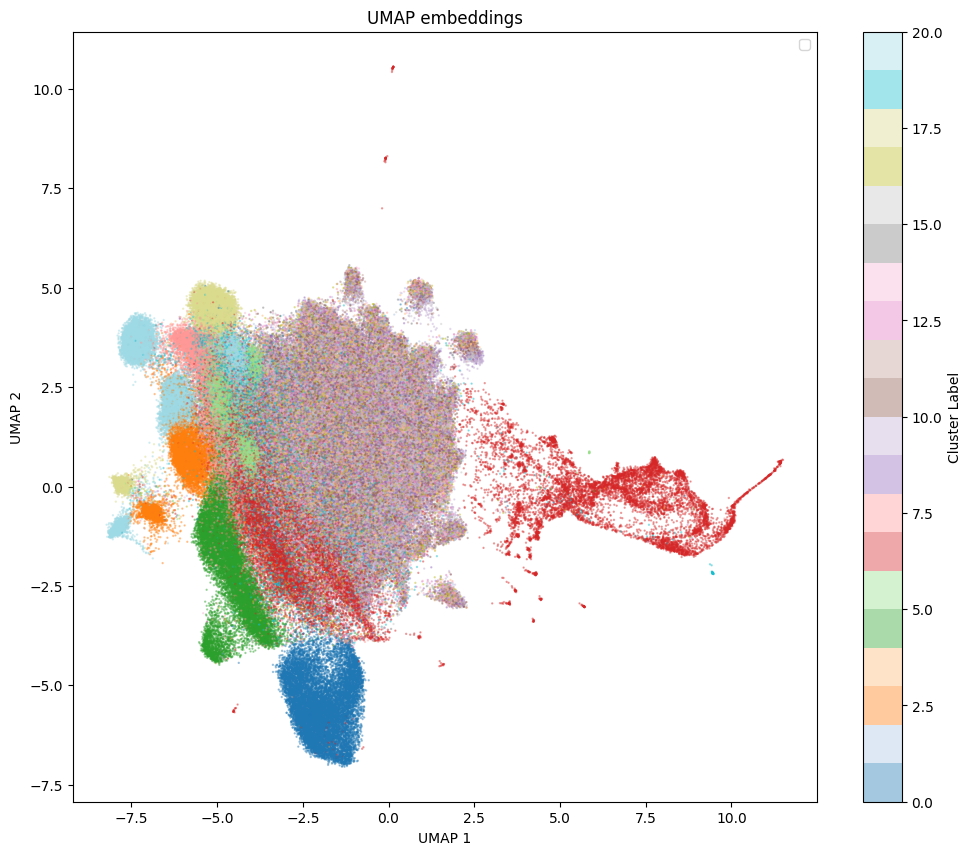

In [26]:
plot_umap_clusters(
    X_umap_2d, clusters, alpha=0.4, cmap="tab20", size=0.5, figsize=(12, 10)
)

0
(array([0]), array([225176]))


/var/folders/1d/mv_j9c7964b105nch0pj7kgh0000gn/T/ipykernel_80235/962237057.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


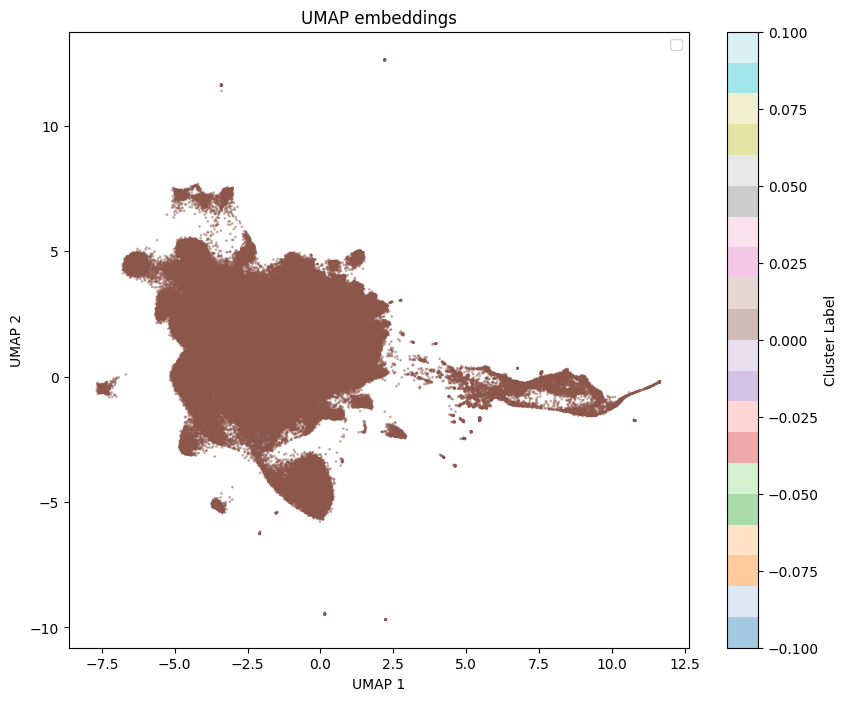

In [ ]:
# umap_model = UMAP(
#     n_components=2,
#     n_neighbors=100,      # większe = gładsza struktura
#     min_dist=0.2,        # większe = bardziej rozproszone klastry
#     metric="cosine",
#     # random_state=42,
# )

plot_umap_clusters(X_umap_2d, [0] * len(X_umap_2d), alpha=0.4, cmap="tab20", size=1)